In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. 
- **Standard linear regression** struggles in these settings because ***it spreads coefficient estimates across correlated features, inflates variance, and can overfit***.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and **adds a penalty term that shrinks coefficient estimates toward zero**, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA



### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [3]:
energy_efficiency = fetch_ucirepo(id=242)

feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [4]:
X = df[['Relative Compactness','Surface Area','Wall Area', 'Roof Area','Overall Height', 'Orientation', 'Glazing Area', 'Glazing Area Distribution']]
y = df['Heating Load']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. 
- Fit it on the training data. 
- Calculate the MSE in a variable called `mse_ols` and 
- inspect the coefficients.

# Use without scale for this bc of autograder issue. After this use X_test_scaled and trained

In [6]:
ols = LinearRegression().fit(X_train, y_train)

y_pred_ols = ols.predict(X_test)

# MSE = average squared difference between predicted value and the actual value 
mse_ols = mean_squared_error(y_test, y_pred_ols)

print(mse_ols)

8.840180473905805


In [7]:
grader.check("q2")

q2 results: All test cases passed!

with scaled data

In [8]:
ols = LinearRegression().fit(X_train_scaled, y_train)

y_pred_ols = ols.predict(X_test_scaled)


mse_ols = mean_squared_error(y_test, y_pred_ols)

print(mse_ols)

8.880089818544722


### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [9]:

lambdas = np.logspace(-4,4,100)

ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring = 'neg_mean_squared_error')

ridge_cv.fit(X_train_scaled,y_train)

ridge_predict = ridge_cv.predict(X_test_scaled)


coef_table = pd.DataFrame({
    'Feature': X.columns,
    'OLS Coefficient': ols.coef_,    # from ols
    'Ridge Coefficient': ridge_cv.coef_  # from ridge_cv
})

print(coef_table)

                     Feature  OLS Coefficient  Ridge Coefficient
0       Relative Compactness    -6.686924e+00          -6.352418
1               Surface Area    -2.898797e+13          -3.474392
2                  Wall Area     1.440817e+13           0.816587
3                  Roof Area     2.962227e+13          -3.797180
4             Overall Height     7.222607e+00           7.306373
5                Orientation    -3.705020e-02          -0.025299
6               Glazing Area     2.901476e+00           2.670852
7  Glazing Area Distribution     8.389402e-02           0.356417


In [10]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**



- Yes, the penalty did its job. The coefficients  Surface Area, Wall Area, and Roof Area in the OLS model are all really big numbers, this could be because they are highly correlated with each other. If the surface area increases it will affect wall and roof area. 
In the ridge model, these coefficients are penalized and shrink close to zero.

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [11]:
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)

#print(y_test_pred_rcv)
print(mse_rcv)

8.843961469551743


In [12]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

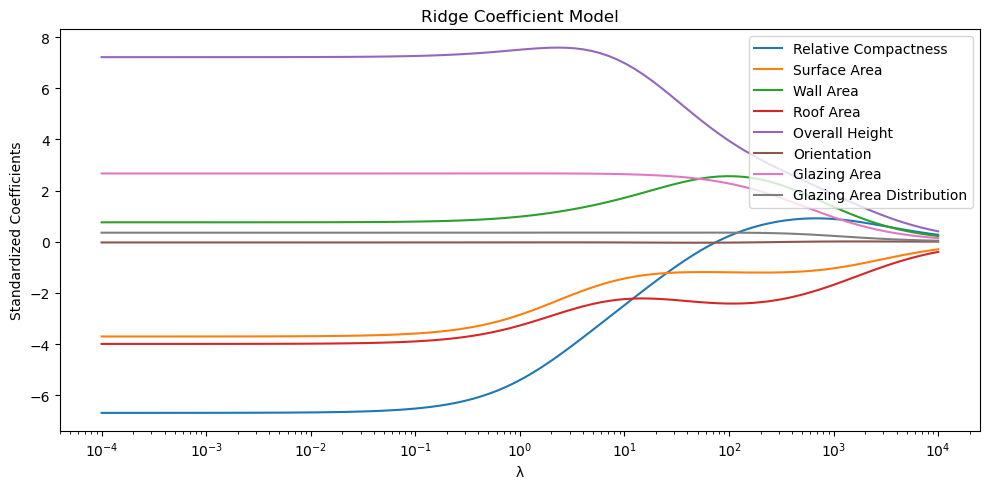

In [13]:
coefs = []
for lam in lambdas:
    ridge = Ridge(alpha=lam).fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)  # convert to (100, 8) array

plt.figure(figsize=(10, 5))
plt.plot(lambdas, coefs, label = X.columns)
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Standardized Coefficients')
plt.title('Ridge Coefficient Model')
plt.legend()
plt.tight_layout()
plt.show()

> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

Relative compact has a large magnitude, it starts near negative 6, and as lambda increases it gets penalized making it shrink, leading to the coefficient/ predictor to be near zero. Also, Overall height, starts at a positive high magnitude but as lambda increases it gets penalized and becomes closer to zero. As both of these coefficients have a large magnitude will have an affect to our response variable of heat load

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [14]:
lambdas = np.logspace(-4,4,100)

lasso_cv = LassoCV(alphas=lambdas, cv=10)

lasso_cv.fit(X_train_scaled,y_train)

lasso_predict = lasso_cv.predict(X_test_scaled)


coef_table = pd.DataFrame({
    'Feature': X.columns,
    'OLS Coefficient': ols.coef_,    # from ols
    'Lasso Coefficient': lasso_cv.coef_,  # from lasso_cv
    'Ridge Coefficient': ridge_cv.coef_

})

print(coef_table)


                     Feature  OLS Coefficient  Lasso Coefficient  \
0       Relative Compactness    -6.686924e+00          -6.418330   
1               Surface Area    -2.898797e+13          -6.231035   
2                  Wall Area     1.440817e+13           2.152524   
3                  Roof Area     2.962227e+13          -1.044324   
4             Overall Height     7.222607e+00           7.309160   
5                Orientation    -3.705020e-02          -0.023593   
6               Glazing Area     2.901476e+00           2.670194   
7  Glazing Area Distribution     8.389402e-02           0.354971   

   Ridge Coefficient  
0          -6.352418  
1          -3.474392  
2           0.816587  
3          -3.797180  
4           7.306373  
5          -0.025299  
6           2.670852  
7           0.356417  


In [15]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

Lasso did not shrink coefficients the same way Ridge did. Ridge spreads the penalty evenly across correlated features (Surface Area, Wall Area, Roof Area), shrinking them all uniformly. Lasso tends to pick one predictor from a correlated group and shrink the others more aggressively. While there was significant shrinkage from OLS to Lasso, Orientation and Glazing Area Distribution were shrunk the most but did not reach exactly zero. Ridge is preferred when all features are believed to be relevant, while Lasso is better for feature selection when you want a simpler, more interpretable model.

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [16]:
# Cross Validation
y_test_pred_lcv = lasso_cv.predict(X_test_scaled)
# Calculate MSE
mse_lcv = mean_squared_error(y_test,y_test_pred_lcv)


print("Lasso Regression MSE:", mse_lcv)

#print("Lasso Regression Cross Validation:", y_test_pred_lcv)


Lasso Regression MSE: 8.841570854996332


In [17]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [18]:
# Create table
mse_table = pd.DataFrame({
    'Model': ['OLS', 'Ridge CV', 'Lasso CV'],
    'Test MSE': [mse_ols, mse_rcv, mse_lcv]
})

#print table
mse_table

,Model,Test MSE
0,OLS,8.880090
1,Ridge CV,8.843961
2,Lasso CV,8.841571


/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.397e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.924e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

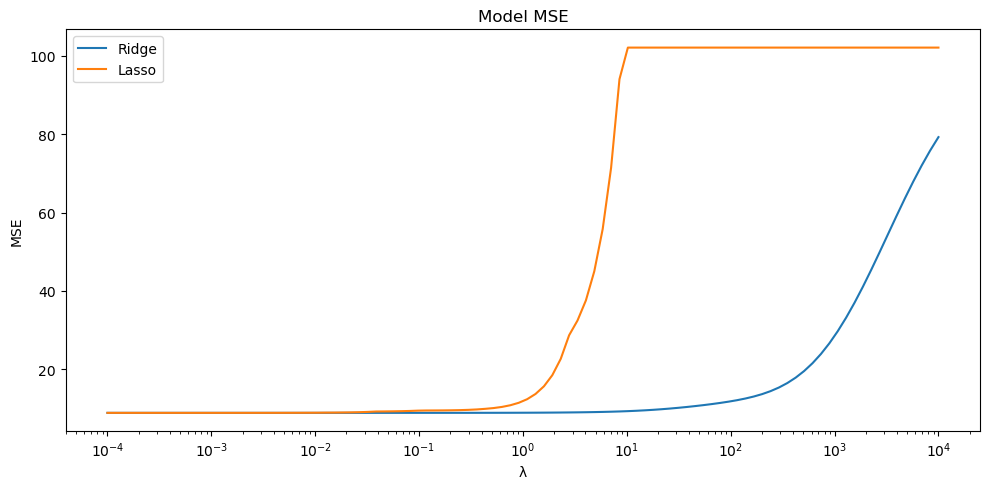

In [19]:
mse_lasso = []
mse_ridge = []

for lam in lambdas:
    ridge = Ridge(alpha=lam).fit(X_train_scaled, y_train)
    lasso = Lasso(alpha=lam).fit(X_train_scaled,y_train)


    mse_lasso.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
    mse_ridge.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))


plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_ridge, label='Ridge')
plt.plot(lambdas, mse_lasso, label='Lasso')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.title('Model MSE')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
coef_table.head()

,Feature,OLS Coefficient,Lasso Coefficient,Ridge Coefficient
0,Relative Compactness,-6.686924e+00,-6.418330,-6.352418
1,Surface Area,-2.898797e+13,-6.231035,-3.474392
2,Wall Area,1.440817e+13,2.152524,0.816587
3,Roof Area,2.962227e+13,-1.044324,-3.797180
4,Overall Height,7.222607e+00,7.309160,7.306373


<Axes: xlabel='Feature'>

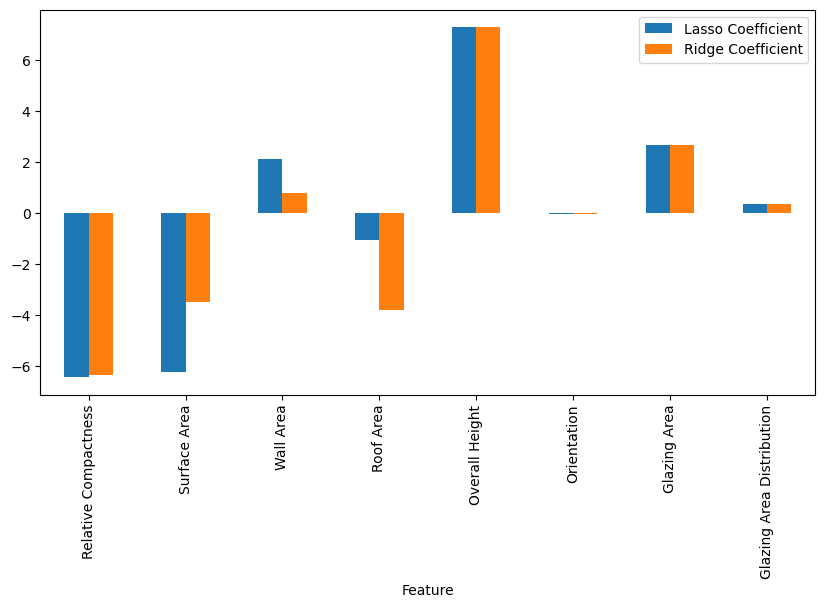

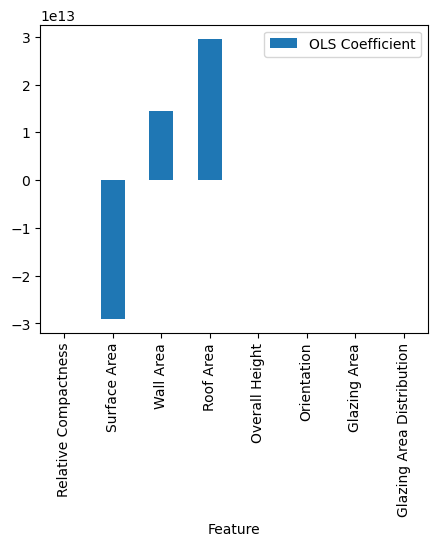

In [21]:
#Ridge and Lasso
coef_table.set_index('Feature')[['Lasso Coefficient', 'Ridge Coefficient']].plot.bar(figsize=(10, 5))
#OLS
coef_table.set_index('Feature')[['OLS Coefficient']].plot.bar(figsize=(5, 4))

OLS has very big coefficients compared to ridge and lasso, if ridge and lasso were plotted on the same plot they would not be visible only OLS. 
In the ridge and lasso plot, the penalty with a ridge model is that it keeps all the predictors in the final model, it also shrinks coefficients towards zero and distributes an equal amount among all coefficients. Whereas lasso penalty tends to select one coefficient from a group of correlated predictors and shrinks the others toward zero.

> **Q4: Which model would you pick for this dataset? Why?**

The model i would pick for this dataset would be Lasso, it will allow me to know which is the best correlated predictor while the other predictors/ coefficients will be at or near zero. Lasso (MSE: 8.841571) also had the lowest MSE compared to ridge (8.843961) and OLS (8.880090) models. Meaning that Lasso is the better choice since the response depends on a small number of strong predictors.

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [22]:
# Fit PCA object on X_train_scaled with all components 
pca_full = PCA(n_components=8).fit(X_train_scaled)

# Store explained variance
explained_var = pca_full.explained_variance_ratio_

# Store cumulative variance 
cumulative_var = np.cumsum(explained_var)

explained_var

# Table showing each component's individual and cumulative variance as % 
pd.DataFrame({
    "Component": range(1, 9),
    "Explained Var (%)": explained_var * 100,
    "Cumulative (%)": cumulative_var * 100,
})

,Component,Explained Var (%),Cumulative (%)
0,1,4.629048e+01,46.290475
1,2,1.563182e+01,61.922293
2,3,1.497484e+01,76.897136
3,4,1.243148e+01,89.328613
4,5,9.966322e+00,99.294935
5,6,6.477268e-01,99.942662
6,7,5.733790e-02,100.000000
7,8,2.730130e-30,100.000000


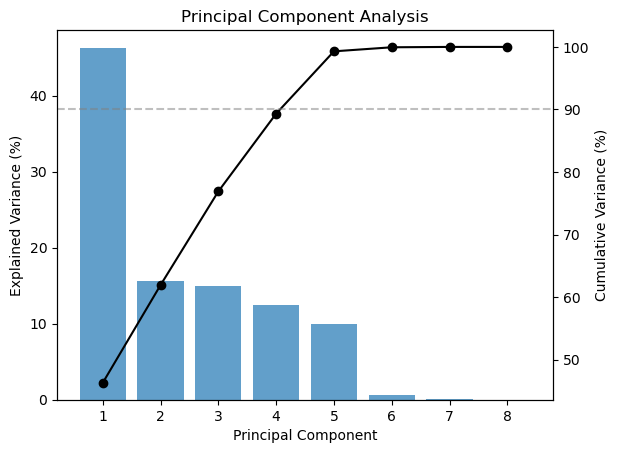

In [23]:
pcs = range(1, 9)
fig, ax1 = plt.subplots()
# individual explained variance for each component - Barplot
ax1.bar(pcs, explained_var * 100, alpha=0.7, label="Individual")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (%)")
# cummulative explained variance - Line plot
ax2 = ax1.twinx()
ax2.plot(pcs, cumulative_var * 100, color="black", marker="o", label="Cumulative")
# horizontal dashed line
ax2.axhline(90, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Cumulative Variance (%)")

plt.title("Principal Component Analysis")
plt.show()

In [24]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

About 4 PC, that is where it is almost 90%

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [25]:
# Set k based on the elbow / ~90% cumulative variance threshold in the plot above
best_k = 4
pca_final = PCA(n_components= best_k).fit(X_train_scaled)
X_train_pca = pca_final.transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

ols_pcr = LinearRegression()
ols_pcr.fit(X_train_pca, y_train)
y_pred_pcr = ols_pcr.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)

print(mse_pcr)

print(cumulative_var)

14.523852865230753
[0.46290475 0.61922293 0.76897136 0.89328613 0.99294935 0.99942662
 1.         1.        ]


<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

I picked 4 for k, since its really close to the cumulative variance at 0.893. I also printed the cumulative_var that was made earlier and that is the closest to 90%, if i would've chosen k=5 where the elbow occurs and the cumulative variance jumped over the 90% variance being at 0.992 -> 99.2%.k=4 has a higher MSE (14.52) than k=5 (12.70) at a lower MSE

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

In [26]:
print(ridge_cv.alpha_)   # best lambda for Ridge
print(lasso_cv.alpha_)   # best lambda for Lasso

0.20565123083486536
0.0016297508346206436


In [27]:
mse_ols

8.880089818544722

In [28]:
pd.DataFrame({
    "Model": ['OLS', 'Ridge', 'Lasso', 'PCR' ],
    "Tuning Parameter": ['None', 'λ = 0.20', 'λ = 0.0016', 'k = 4'],
    "Test MSE": [mse_ols, mse_lcv, mse_rcv, mse_pcr]
})

,Model,Tuning Parameter,Test MSE
0,OLS,None,8.880090
1,Ridge,λ = 0.20,8.841571
2,Lasso,λ = 0.0016,8.843961
3,PCR,k = 4,14.523853


For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

The lowest MSE is the model ridge at 8.841, compared to PCR of 14.52 which increased substantially. PCR is still taking into account all variables when forming linear combinations of the predictors to create the PC. Ridge now performs differently than lasso and ols. PCR cannot perform variable selection. For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response.
### confused bc lasso performed best before PCR was introduced. not ridge performs better then lasso with a lower mse. however in the class notes it says it lasso tends to perform best becuase it the predictors can be exactly zero (not the case here, its mostly near)

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [29]:
grader.check_all()

q1 results: All test cases passed!

q2 results:
    q2 - 1 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(mse_ols, 8.8395, atol=0.01)
        Expecting nothing
        **********************************************************************
        Line 1, in q2 0
        Failed example:
            assert np.isclose(mse_ols, 8.8395, atol=0.01)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q2 0[0]>", line 1, in <module>
                assert np.isclose(mse_ols, 8.8395, atol=0.01)
            AssertionError

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!